# 🌱 Green Supply Chain Analytics

**A single-notebook Data Analytics & BI portfolio project.**

Pure analytics — descriptive, diagnostic, prescriptive. No machine learning, no predictive modeling.

**Pipeline:** Data Cleaning → KPI Engineering → SQL (SQLite, CTEs + window functions) → Statistical Diagnostics (SciPy) → Visualization (Matplotlib/Seaborn) → Excel Dashboard (XlsxWriter) → Word Report (python-docx)

**Dataset:** 1,000 supply chain records across 5 product categories (Electronics, Apparel, Automotive, Pharmaceutical, Food).


## 0. Setup & Imports


In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
PALETTE = 'viridis'
pd.set_option('display.max_columns', None)

RAW_PATH = 'data/raw/green_supply_chain_dataset_1000.csv'
PROCESSED_PATH = 'data/processed/cleaned_supply_chain.csv'
DB_PATH = 'data/processed/supply_chain.db'
EXCEL_PATH = 'exports/Green_Supply_Chain_Dashboard.xlsx'
DOCX_PATH = 'reports/Sustainability_Insights_Report.docx'

os.makedirs('data/processed', exist_ok=True)
os.makedirs('charts', exist_ok=True)
os.makedirs('exports', exist_ok=True)
os.makedirs('reports', exist_ok=True)

print('Setup complete.')


Setup complete.


## 1. Load & Inspect Raw Data

Loading the raw CSV and checking schema, shape, and basic data quality before cleaning.


In [2]:
raw_df = pd.read_csv(RAW_PATH)
print(f'Shape: {raw_df.shape}')
raw_df.head()


Shape: (1000, 12)


   ID    Product_Type  Raw_Material_Usage_kg  Energy_Consumption_kWh  \
0   1  Pharmaceutical             187.102474              372.345525   
1   2            Food             117.375305               82.437951   
2   3      Automotive             142.363657               82.065527   
3   4            Food             185.274882               55.448814   
4   5            Food             144.375341              480.425629   

   Waste_Generated_kg  Transport_Distance_km  CO2_Emissions_kg  \
0            4.580997            2708.230192        206.072501   
1           31.494820             605.998543        794.003359   
2           49.077714             945.366997        166.372969   
3           10.315275            2883.074057        653.161326   
4           39.837161            1552.152306        167.653725   

   Manufacturing_Energy_kWh  Renewable_Energy_%       Cost_$  \
0                195.022097           77.312801  4696.896464   
1                784.206729           31.8

In [3]:
raw_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        1000 non-null   int64  
 1   Product_Type              1000 non-null   str    
 2   Raw_Material_Usage_kg     1000 non-null   float64
 3   Energy_Consumption_kWh    1000 non-null   float64
 4   Waste_Generated_kg        1000 non-null   float64
 5   Transport_Distance_km     1000 non-null   float64
 6   CO2_Emissions_kg          1000 non-null   float64
 7   Manufacturing_Energy_kWh  1000 non-null   float64
 8   Renewable_Energy_%        1000 non-null   float64
 9   Cost_$                    1000 non-null   float64
 10  Delivery_Time_days        1000 non-null   int64  
 11  Sustainability_Score      1000 non-null   float64
dtypes: float64(9), int64(2), str(1)
memory usage: 93.9 KB


In [4]:
# Quick data quality scan: nulls, duplicates, negative values
print('Nulls per column:')
print(raw_df.isnull().sum())
print(f'\nDuplicate rows: {raw_df.duplicated().sum()}')
print(f'Duplicate IDs: {raw_df["ID"].duplicated().sum()}')


Nulls per column:
ID                          0
Product_Type                0
Raw_Material_Usage_kg       0
Energy_Consumption_kWh      0
Waste_Generated_kg          0
Transport_Distance_km       0
CO2_Emissions_kg            0
Manufacturing_Energy_kWh    0
Renewable_Energy_%          0
Cost_$                      0
Delivery_Time_days          0
Sustainability_Score        0
dtype: int64

Duplicate rows: 0
Duplicate IDs: 0


## 2. Data Cleaning

Standardize column names to snake_case, remove duplicates, clip invalid negative values, bound percentage/score columns to [0, 100], and drop rows with nulls in critical fields.


In [5]:
def standardize_columns(df):
    rename_map = {
        'ID': 'id', 'Product_Type': 'product_type',
        'Raw_Material_Usage_kg': 'raw_material_usage_kg',
        'Energy_Consumption_kWh': 'energy_consumption_kwh',
        'Waste_Generated_kg': 'waste_generated_kg',
        'Transport_Distance_km': 'transport_distance_km',
        'CO2_Emissions_kg': 'co2_emissions_kg',
        'Manufacturing_Energy_kWh': 'manufacturing_energy_kwh',
        'Renewable_Energy_%': 'renewable_energy_pct',
        'Cost_$': 'cost_usd', 'Delivery_Time_days': 'delivery_time_days',
        'Sustainability_Score': 'sustainability_score',
    }
    return df.rename(columns=rename_map)


def clean(df):
    df = df.copy()
    df = df.drop_duplicates()
    df = df.drop_duplicates(subset='id', keep='first')

    numeric_cols = [
        'raw_material_usage_kg', 'energy_consumption_kwh', 'waste_generated_kg',
        'transport_distance_km', 'co2_emissions_kg', 'manufacturing_energy_kwh',
        'renewable_energy_pct', 'cost_usd', 'delivery_time_days', 'sustainability_score',
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').clip(lower=0)

    df['renewable_energy_pct'] = df['renewable_energy_pct'].clip(upper=100)
    df['sustainability_score'] = df['sustainability_score'].clip(upper=100)

    critical = ['product_type', 'cost_usd', 'co2_emissions_kg', 'sustainability_score']
    df = df.dropna(subset=critical)
    df['product_type'] = df['product_type'].astype(str).str.strip().str.title()
    return df.reset_index(drop=True)


def engineer_kpis(df):
    df = df.copy()
    safe_cost = df['cost_usd'].replace(0, np.nan)
    safe_distance = df['transport_distance_km'].replace(0, np.nan)
    safe_raw_material = df['raw_material_usage_kg'].replace(0, np.nan)

    df['carbon_intensity_per_dollar'] = df['co2_emissions_kg'] / safe_cost
    df['carbon_intensity_per_km'] = df['co2_emissions_kg'] / safe_distance
    df['waste_to_output_ratio'] = df['waste_generated_kg'] / safe_raw_material
    df['eco_efficiency_index'] = df['sustainability_score'] / (df['cost_usd'] / 1000)
    df['renewable_adoption_rate'] = df['renewable_energy_pct']

    kpi_cols = ['carbon_intensity_per_dollar', 'carbon_intensity_per_km',
                'waste_to_output_ratio', 'eco_efficiency_index']
    df[kpi_cols] = df[kpi_cols].fillna(0)
    return df


df = standardize_columns(raw_df)
df = clean(df)
df = engineer_kpis(df)
df.to_csv(PROCESSED_PATH, index=False)
print(f'Cleaned dataset: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()


Cleaned dataset: 1000 rows, 17 columns


   id    product_type  raw_material_usage_kg  energy_consumption_kwh  \
0   1  Pharmaceutical             187.102474              372.345525   
1   2            Food             117.375305               82.437951   
2   3      Automotive             142.363657               82.065527   
3   4            Food             185.274882               55.448814   
4   5            Food             144.375341              480.425629   

   waste_generated_kg  transport_distance_km  co2_emissions_kg  \
0            4.580997            2708.230192        206.072501   
1           31.494820             605.998543        794.003359   
2           49.077714             945.366997        166.372969   
3           10.315275            2883.074057        653.161326   
4           39.837161            1552.152306        167.653725   

   manufacturing_energy_kwh  renewable_energy_pct     cost_usd  \
0                195.022097             77.312801  4696.896464   
1                784.206729           

## 3. Core KPI Dictionary

| KPI | Formula | Business Question |
|---|---|---|
| Carbon Intensity per Dollar | `co2_emissions_kg / cost_usd` | Emissions per dollar spent |
| Carbon Intensity per KM | `co2_emissions_kg / transport_distance_km` | Is transport the emissions bottleneck? |
| Renewable Energy Adoption Rate | `renewable_energy_pct` | Green-energy transition progress |
| Waste-to-Output Ratio | `waste_generated_kg / raw_material_usage_kg` | Process efficiency |
| Eco-Efficiency Index | `sustainability_score / (cost_usd / 1000)` | Sustainability per $1000 spent |


In [6]:
kpi_cols = ['carbon_intensity_per_dollar', 'carbon_intensity_per_km',
            'waste_to_output_ratio', 'eco_efficiency_index', 'renewable_adoption_rate']
df[kpi_cols].describe().round(4)


       carbon_intensity_per_dollar  carbon_intensity_per_km  \
count                    1000.0000                1000.0000   
mean                        0.3579                   0.4345   
std                         0.4663                   0.7378   
min                         0.0135                   0.0128   
25%                         0.1120                   0.1054   
50%                         0.2093                   0.2061   
75%                         0.3980                   0.3997   
max                         4.4447                   8.1503   

       waste_to_output_ratio  eco_efficiency_index  renewable_adoption_rate  
count              1000.0000             1000.0000                1000.0000  
mean                  0.4067               36.7540                  44.1530  
std                   0.5262               44.2142                  20.0104  
min                   0.0079                3.3418                  10.0169  
25%                   0.1306              

## 4. SQL Analysis Layer (SQLite)

Loading the cleaned data into SQLite to run real analytical SQL — CTEs and window functions — directly from the notebook. SQLite is built into Python (no server install); this SQL is portable to PostgreSQL/BigQuery with no syntax changes.


In [7]:
conn = sqlite3.connect(DB_PATH)
df.to_sql('supply_chain', conn, if_exists='replace', index=False)
print(f"Loaded {conn.execute('SELECT COUNT(*) FROM supply_chain').fetchone()[0]} rows into SQLite")


Loaded 1000 rows into SQLite


### 4.1 Eco-Efficiency Quadrant by Category


In [8]:
eco_efficiency_sql = '''
WITH category_summary AS (
    SELECT product_type,
           ROUND(AVG(cost_usd), 2) AS avg_cost,
           ROUND(AVG(sustainability_score), 2) AS avg_sustainability_score,
           COUNT(*) AS n_records
    FROM supply_chain
    GROUP BY product_type
),
overall AS (
    SELECT AVG(cost_usd) AS overall_avg_cost, AVG(sustainability_score) AS overall_avg_score
    FROM supply_chain
)
SELECT cs.product_type, cs.avg_cost, cs.avg_sustainability_score, cs.n_records,
    CASE
        WHEN cs.avg_cost >= o.overall_avg_cost AND cs.avg_sustainability_score >= o.overall_avg_score THEN 'Premium & Sustainable'
        WHEN cs.avg_cost < o.overall_avg_cost AND cs.avg_sustainability_score >= o.overall_avg_score THEN 'Eco Champion'
        WHEN cs.avg_cost >= o.overall_avg_cost AND cs.avg_sustainability_score < o.overall_avg_score THEN 'Inefficient Laggard'
        ELSE 'Budget & Low Impact'
    END AS eco_quadrant
FROM category_summary cs CROSS JOIN overall o
ORDER BY cs.avg_sustainability_score DESC;
'''
eco_quadrant_df = pd.read_sql(eco_efficiency_sql, conn)
eco_quadrant_df


     product_type  avg_cost  avg_sustainability_score  n_records  \
0            Food   2419.76                     52.63        204   
1  Pharmaceutical   2479.58                     52.18        206   
2     Electronics   2595.34                     50.44        210   
3      Automotive   2641.94                     50.40        190   
4         Apparel   2375.51                     50.27        190   

          eco_quadrant  
0         Eco Champion  
1         Eco Champion  
2  Inefficient Laggard  
3  Inefficient Laggard  
4  Budget & Low Impact  


### 4.2 High-Risk Flagging (CTE + Window Function: `RANK()`)


In [9]:
high_risk_sql = '''
WITH category_stats AS (
    SELECT s.product_type AS product_type,
           AVG(s.sustainability_score) AS avg_category_score,
           SQRT(AVG((s.sustainability_score - sub.avg_score) * (s.sustainability_score - sub.avg_score))) AS stddev_category_score,
           AVG(s.co2_emissions_kg * 1.0 / NULLIF(s.cost_usd, 0)) AS avg_carbon_per_dollar
    FROM supply_chain s
    JOIN (SELECT product_type, AVG(sustainability_score) AS avg_score FROM supply_chain GROUP BY product_type) sub
      ON s.product_type = sub.product_type
    GROUP BY s.product_type
),
scored_records AS (
    SELECT s.id, s.product_type, s.sustainability_score, s.co2_emissions_kg, s.cost_usd,
        ROUND(s.co2_emissions_kg * 1.0 / NULLIF(s.cost_usd, 0), 4) AS carbon_per_dollar,
        cs.avg_category_score, cs.stddev_category_score, cs.avg_carbon_per_dollar,
        RANK() OVER (PARTITION BY s.product_type ORDER BY s.sustainability_score ASC) AS sustainability_rank_in_category,
        ROUND((s.sustainability_score - cs.avg_category_score) * 1.0 / NULLIF(cs.stddev_category_score, 0), 2) AS z_score
    FROM supply_chain s
    JOIN category_stats cs ON s.product_type = cs.product_type
)
SELECT id, product_type, sustainability_score, carbon_per_dollar,
    z_score AS sustainability_z_score, sustainability_rank_in_category,
    CASE
        WHEN z_score < -1.0 AND carbon_per_dollar > avg_carbon_per_dollar THEN 'HIGH RISK'
        WHEN z_score < -0.5 THEN 'WATCH LIST'
        ELSE 'ACCEPTABLE'
    END AS risk_flag
FROM scored_records
WHERE sustainability_rank_in_category <= 50
ORDER BY product_type, sustainability_rank_in_category;
'''
high_risk_df = pd.read_sql(high_risk_sql, conn)
print(high_risk_df['risk_flag'].value_counts())
high_risk_df.head(10)


risk_flag
WATCH LIST    184
HIGH RISK      66
Name: count, dtype: int64


    id product_type  sustainability_score  carbon_per_dollar  \
0  717      Apparel                 12.80             0.2415   
1  774      Apparel                 16.71             0.6431   
2  194      Apparel                 16.89             0.1849   
3  966      Apparel                 18.24             0.2745   
4  927      Apparel                 19.77             0.6414   
5  539      Apparel                 22.49             0.2438   
6  352      Apparel                 22.83             0.1957   
7  787      Apparel                 23.61             0.1877   
8  718      Apparel                 23.87             0.2062   
9  777      Apparel                 25.24             0.5268   

   sustainability_z_score  sustainability_rank_in_category   risk_flag  
0                   -2.53                                1  WATCH LIST  
1                   -2.27                                2   HIGH RISK  
2                   -2.25                                3  WATCH LIST  
3  

### 4.3 Waste & Renewable Energy Audit


In [10]:
waste_audit_sql = '''
WITH category_metrics AS (
    SELECT product_type,
        ROUND(AVG(waste_generated_kg * 1.0 / NULLIF(raw_material_usage_kg, 0)), 4) AS avg_waste_to_output_ratio,
        ROUND(AVG(renewable_energy_pct), 2) AS avg_renewable_pct,
        ROUND(AVG(sustainability_score), 2) AS avg_sustainability_score,
        COUNT(*) AS n_records
    FROM supply_chain GROUP BY product_type
),
overall AS (
    SELECT AVG(waste_generated_kg * 1.0 / NULLIF(raw_material_usage_kg, 0)) AS overall_avg_waste_ratio,
           AVG(renewable_energy_pct) AS overall_avg_renewable
    FROM supply_chain
)
SELECT cm.*,
    CASE
        WHEN cm.avg_waste_to_output_ratio > o.overall_avg_waste_ratio AND cm.avg_renewable_pct < o.overall_avg_renewable THEN 'PRIORITY: Waste + Renewable Investment'
        WHEN cm.avg_waste_to_output_ratio > o.overall_avg_waste_ratio THEN 'FOCUS: Waste Reduction'
        WHEN cm.avg_renewable_pct < o.overall_avg_renewable THEN 'FOCUS: Renewable Energy Adoption'
        ELSE 'ON TRACK'
    END AS recommended_focus
FROM category_metrics cm CROSS JOIN overall o
ORDER BY cm.avg_sustainability_score ASC;
'''
waste_audit_df = pd.read_sql(waste_audit_sql, conn)
waste_audit_df


     product_type  avg_waste_to_output_ratio  avg_renewable_pct  \
0         Apparel                     0.3925              43.31   
1      Automotive                     0.3830              41.38   
2     Electronics                     0.4274              45.10   
3  Pharmaceutical                     0.3981              44.98   
4            Food                     0.4292              45.71   

   avg_sustainability_score  n_records                 recommended_focus  
0                     50.27        190  FOCUS: Renewable Energy Adoption  
1                     50.40        190  FOCUS: Renewable Energy Adoption  
2                     50.44        210            FOCUS: Waste Reduction  
3                     52.18        206                          ON TRACK  
4                     52.63        204            FOCUS: Waste Reduction  


## 5. Statistical Diagnostics (SciPy)

Going beyond simple averages: is category actually a statistically significant driver of sustainability outcomes, or is the variation just noise? Which factors correlate most strongly with the target? Which records are true outliers?


### 5.1 One-Way ANOVA: Sustainability Score by Product Type


In [11]:
groups = [g['sustainability_score'].values for _, g in df.groupby('product_type')]
f_stat, p_value = stats.f_oneway(*groups)
print(f'F-statistic: {f_stat:.4f}')
print(f'p-value:     {p_value:.6f}')
if p_value < 0.05:
    print('=> Product type HAS a statistically significant effect on sustainability score.')
else:
    print('=> No statistically significant difference in sustainability score across product types.')


F-statistic: 1.1766
p-value:     0.319491
=> No statistically significant difference in sustainability score across product types.


### 5.2 Correlation Analysis


In [12]:
numeric_cols = ['raw_material_usage_kg', 'energy_consumption_kwh', 'waste_generated_kg',
                'transport_distance_km', 'co2_emissions_kg', 'manufacturing_energy_kwh',
                'renewable_energy_pct', 'cost_usd', 'delivery_time_days', 'sustainability_score']
corr_matrix = df[numeric_cols].corr(method='pearson').round(3)

corr_with_target = corr_matrix['sustainability_score'].drop('sustainability_score')
top_corr = pd.DataFrame({
    'factor': corr_with_target.index,
    'correlation': corr_with_target.values,
    'abs_correlation': corr_with_target.abs().values,
}).sort_values('abs_correlation', ascending=False).reset_index(drop=True)
top_corr


                     factor  correlation  abs_correlation
0      renewable_energy_pct        0.701            0.701
1          co2_emissions_kg       -0.564            0.564
2        waste_generated_kg       -0.464            0.464
3                  cost_usd       -0.179            0.179
4     transport_distance_km        0.034            0.034
5    energy_consumption_kwh        0.018            0.018
6  manufacturing_energy_kwh       -0.012            0.012
7     raw_material_usage_kg        0.011            0.011
8        delivery_time_days        0.001            0.001


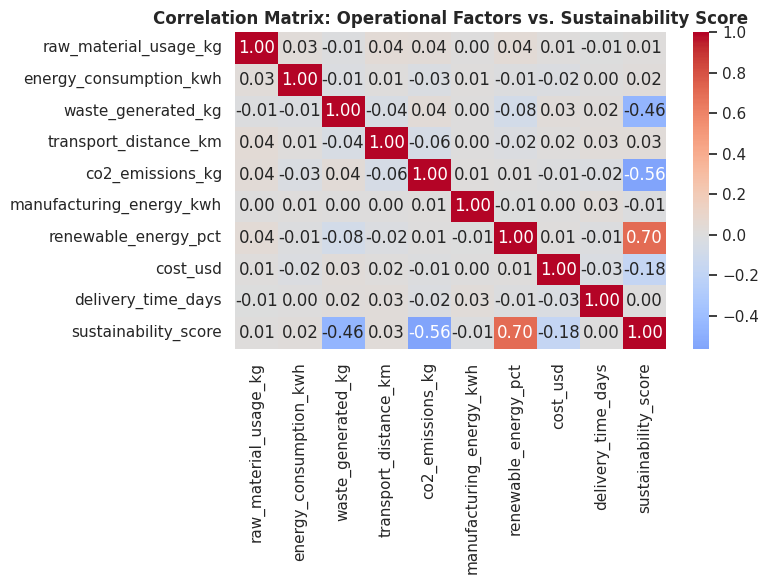

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Correlation Matrix: Operational Factors vs. Sustainability Score', fontsize=12, weight='bold')
plt.tight_layout()
plt.savefig('charts/05_correlation_heatmap.png', dpi=150)
plt.show()


### 5.3 Statistical Outlier Detection (Z-Score)


In [14]:
z_scores = np.abs(stats.zscore(df['sustainability_score']))
outliers = df.loc[z_scores > 2.5, ['id', 'product_type', 'sustainability_score']].copy()
outliers['z_score'] = z_scores[z_scores > 2.5].round(2)
outliers = outliers.sort_values('z_score', ascending=False)
print(f'{len(outliers)} statistical outliers detected (|z| > 2.5)')
outliers


5 statistical outliers detected (|z| > 2.5)


      id    product_type  sustainability_score  z_score
475  476            Food                 91.53     2.73
88    89  Pharmaceutical                 90.22     2.64
198  199            Food                 89.54     2.60
716  717         Apparel                 12.80     2.60
872  873     Electronics                 88.67     2.54


### 5.4 Category Summary Statistics


In [15]:
category_summary = df.groupby('product_type')['sustainability_score'].agg(
    mean='mean', median='median', std='std', min='min', max='max'
).round(2)
category_summary['iqr'] = (
    df.groupby('product_type')['sustainability_score'].quantile(0.75)
    - df.groupby('product_type')['sustainability_score'].quantile(0.25)
).round(2)
category_summary.reset_index()


     product_type   mean  median    std    min    max    iqr
0         Apparel  50.27   49.46  14.85  12.80  84.02  20.01
1      Automotive  50.40   50.28  14.59  16.49  86.82  20.43
2     Electronics  50.44   50.40  14.83  17.25  88.67  23.12
3            Food  52.63   52.73  14.41  18.00  91.53  20.86
4  Pharmaceutical  52.18   50.83  15.12  20.56  90.22  23.73


## 6. Visualizations

Four core charts answering the project's three strategic analytical angles, rendered inline with Matplotlib/Seaborn and saved to `/charts`.


### 6.1 Eco-Efficiency Matrix: Cost vs. Sustainability Score


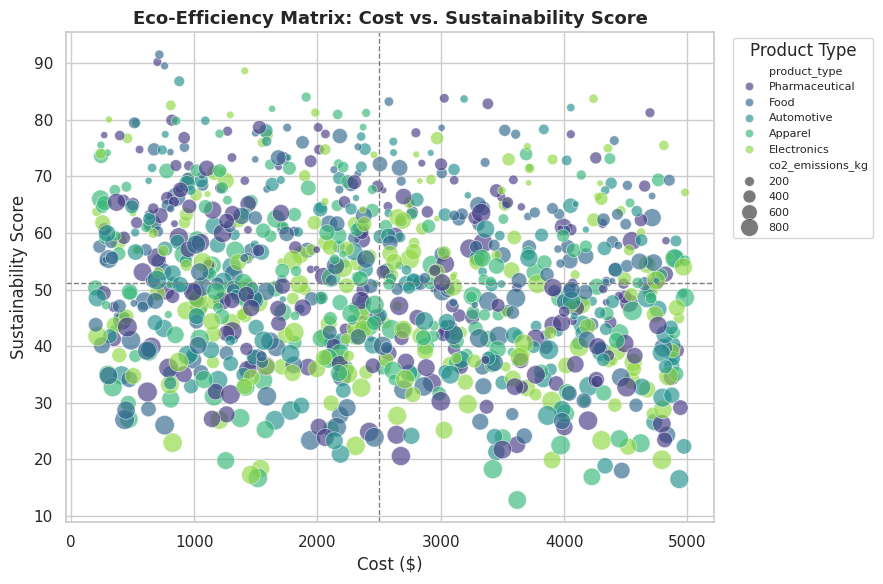

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df, x='cost_usd', y='sustainability_score', hue='product_type',
                size='co2_emissions_kg', sizes=(20, 200), alpha=0.65, palette=PALETTE, ax=ax)
ax.axvline(df['cost_usd'].mean(), linestyle='--', color='gray', linewidth=1)
ax.axhline(df['sustainability_score'].mean(), linestyle='--', color='gray', linewidth=1)
ax.set_title('Eco-Efficiency Matrix: Cost vs. Sustainability Score', fontsize=13, weight='bold')
ax.set_xlabel('Cost ($)'); ax.set_ylabel('Sustainability Score')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Product Type')
plt.tight_layout()
plt.savefig('charts/01_eco_efficiency_matrix.png', dpi=150)
plt.show()


### 6.2 Carbon Intensity per KM by Product Type


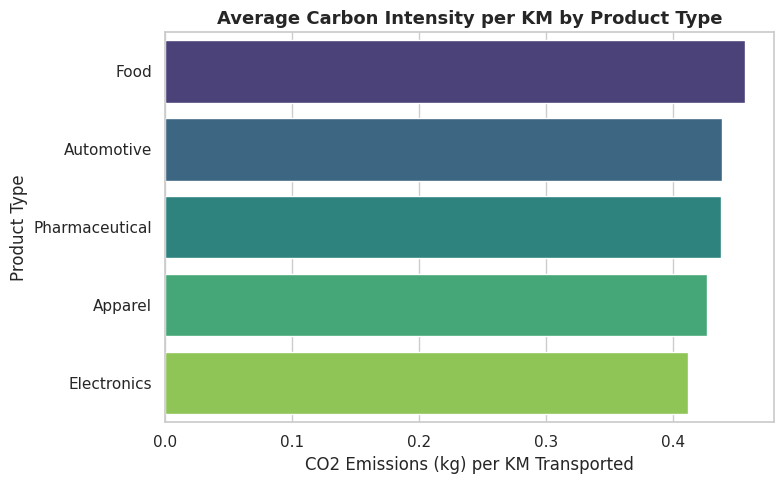

In [17]:
carbon_summary = df.groupby('product_type')['carbon_intensity_per_km'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=carbon_summary.values, y=carbon_summary.index, hue=carbon_summary.index, palette=PALETTE, ax=ax, legend=False)
ax.set_title('Average Carbon Intensity per KM by Product Type', fontsize=13, weight='bold')
ax.set_xlabel('CO2 Emissions (kg) per KM Transported'); ax.set_ylabel('Product Type')
plt.tight_layout()
plt.savefig('charts/02_carbon_intensity_per_km.png', dpi=150)
plt.show()


### 6.3 Waste & Renewable Energy Audit


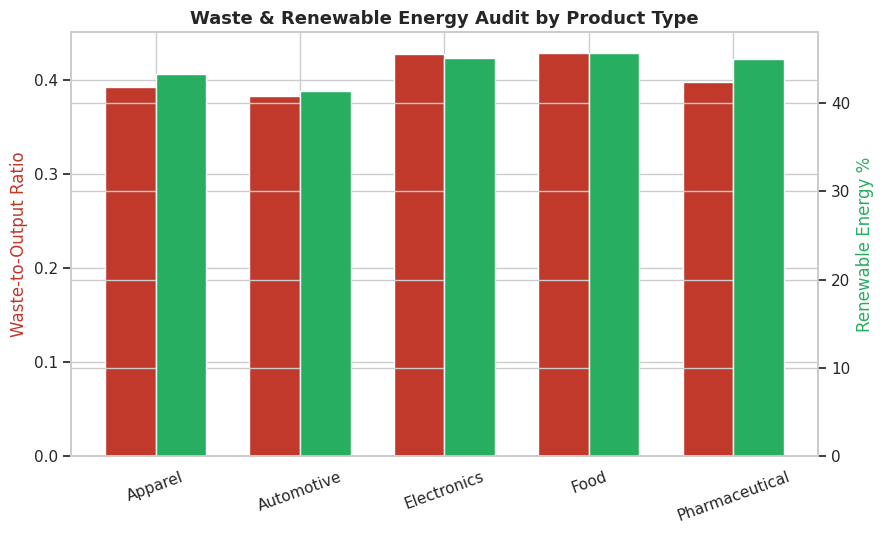

In [18]:
waste_renewable = df.groupby('product_type').agg(
    avg_waste_ratio=('waste_to_output_ratio', 'mean'),
    avg_renewable_pct=('renewable_energy_pct', 'mean'),
).reset_index()

fig, ax1 = plt.subplots(figsize=(9, 5.5))
x = range(len(waste_renewable)); width = 0.35
ax1.bar([i - width/2 for i in x], waste_renewable['avg_waste_ratio'], width=width, color='#c0392b', label='Avg Waste-to-Output Ratio')
ax1.set_ylabel('Waste-to-Output Ratio', color='#c0392b')
ax1.set_xticks(list(x)); ax1.set_xticklabels(waste_renewable['product_type'], rotation=20)
ax2 = ax1.twinx()
ax2.bar([i + width/2 for i in x], waste_renewable['avg_renewable_pct'], width=width, color='#27ae60', label='Avg Renewable Energy %')
ax2.set_ylabel('Renewable Energy %', color='#27ae60')
ax1.set_title('Waste & Renewable Energy Audit by Product Type', fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig('charts/03_waste_renewable_audit.png', dpi=150)
plt.show()


### 6.4 Sustainability Score Distribution


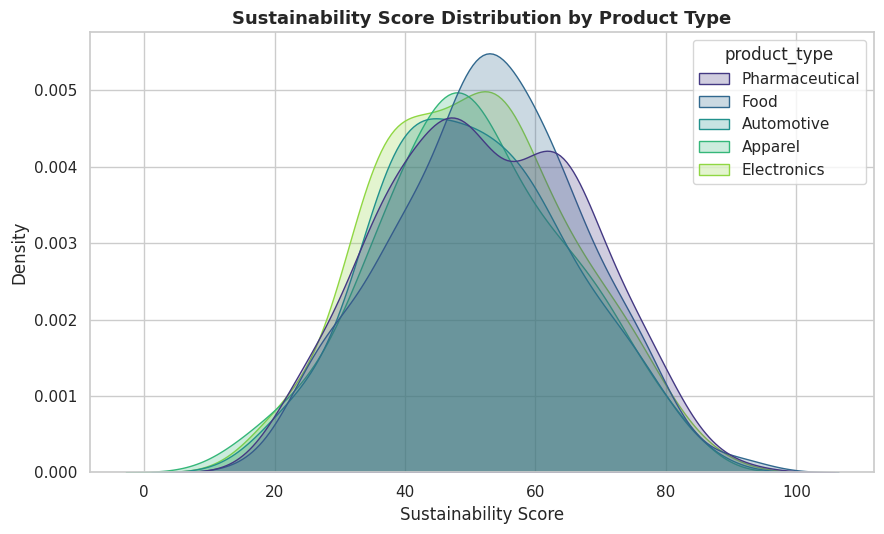

In [19]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.kdeplot(data=df, x='sustainability_score', hue='product_type', fill=True, alpha=0.25, palette=PALETTE, ax=ax)
ax.set_title('Sustainability Score Distribution by Product Type', fontsize=13, weight='bold')
ax.set_xlabel('Sustainability Score')
plt.tight_layout()
plt.savefig('charts/04_sustainability_score_distribution.png', dpi=150)
plt.show()


## 7. Excel Dashboard Export (XlsxWriter)

Builds a 6-sheet workbook with **native Excel charts** (not pasted images) — a stakeholder can open this and filter/sort the raw data or interact with the charts directly.


In [20]:
import xlsxwriter

workbook = xlsxwriter.Workbook(EXCEL_PATH)
header_fmt = workbook.add_format({'bold': True, 'bg_color': '#2E7D32', 'font_color': 'white', 'border': 1, 'align': 'center'})
title_fmt = workbook.add_format({'bold': True, 'font_size': 14, 'font_color': '#1B5E20'})

# --- Raw Data ---
ws_raw = workbook.add_worksheet('Raw_Data')
ws_raw.write_row(0, 0, df.columns, header_fmt)
for i, col in enumerate(df.columns):
    ws_raw.set_column(i, i, max(12, len(col) + 2))
for r, row in enumerate(df.itertuples(index=False), start=1):
    ws_raw.write_row(r, 0, row)
ws_raw.freeze_panes(1, 0)
ws_raw.autofilter(0, 0, len(df), len(df.columns) - 1)

# --- KPI Summary ---
kpi_summary = df.groupby('product_type').agg(
    avg_cost=('cost_usd', 'mean'), avg_sustainability_score=('sustainability_score', 'mean'),
    avg_carbon_intensity_per_dollar=('carbon_intensity_per_dollar', 'mean'),
    avg_carbon_intensity_per_km=('carbon_intensity_per_km', 'mean'),
    avg_waste_to_output_ratio=('waste_to_output_ratio', 'mean'),
    avg_renewable_pct=('renewable_energy_pct', 'mean'),
    avg_eco_efficiency_index=('eco_efficiency_index', 'mean'), n_records=('id', 'count'),
).round(3).reset_index()

ws_kpi = workbook.add_worksheet('KPI_Summary')
ws_kpi.merge_range(0, 0, 0, 7, 'Core KPI Dictionary — Per Product Category', title_fmt)
ws_kpi.write_row(2, 0, kpi_summary.columns, header_fmt)
for i, col in enumerate(kpi_summary.columns):
    ws_kpi.set_column(i, i, 26)
for r, row in enumerate(kpi_summary.itertuples(index=False), start=3):
    ws_kpi.write_row(r, 0, row)
score_col = kpi_summary.columns.get_loc('avg_sustainability_score')
ws_kpi.conditional_format(3, score_col, 2 + len(kpi_summary), score_col,
    {'type': '3_color_scale', 'min_color': '#F8696B', 'mid_color': '#FFEB84', 'max_color': '#63BE7B'})

print('Raw_Data and KPI_Summary sheets built.')


Raw_Data and KPI_Summary sheets built.


In [21]:
# --- Carbon Intensity native bar chart ---
ws_carbon = workbook.add_worksheet('Carbon_Intensity')
ws_carbon.merge_range(0, 0, 0, 2, 'Average Carbon Intensity per KM by Product Type', title_fmt)
carbon_tbl = df.groupby('product_type')['carbon_intensity_per_km'].mean().round(4).sort_values(ascending=False).reset_index()
ws_carbon.write_row(2, 0, ['product_type', 'avg_carbon_intensity_per_km'], header_fmt)
for r, row in enumerate(carbon_tbl.itertuples(index=False), start=3):
    ws_carbon.write_row(r, 0, row)
chart_carbon = workbook.add_chart({'type': 'bar'})
chart_carbon.add_series({
    'name': 'Avg Carbon Intensity per KM',
    'categories': ['Carbon_Intensity', 3, 0, 2 + len(carbon_tbl), 0],
    'values': ['Carbon_Intensity', 3, 1, 2 + len(carbon_tbl), 1],
    'fill': {'color': '#2E7D32'},
})
chart_carbon.set_title({'name': 'Carbon Intensity per KM by Product Type'})
chart_carbon.set_size({'width': 640, 'height': 400})
ws_carbon.insert_chart('E3', chart_carbon)

# --- Waste & Renewable combo chart ---
ws_waste = workbook.add_worksheet('Waste_Renewable')
ws_waste.merge_range(0, 0, 0, 2, 'Waste-to-Output Ratio vs. Renewable Energy % by Category', title_fmt)
waste_tbl = df.groupby('product_type').agg(
    avg_waste_to_output_ratio=('waste_to_output_ratio', 'mean'),
    avg_renewable_pct=('renewable_energy_pct', 'mean'),
).round(3).reset_index()
ws_waste.write_row(2, 0, waste_tbl.columns, header_fmt)
for r, row in enumerate(waste_tbl.itertuples(index=False), start=3):
    ws_waste.write_row(r, 0, row)
c1 = workbook.add_chart({'type': 'column'})
c1.add_series({'name': 'Avg Waste-to-Output Ratio',
    'categories': ['Waste_Renewable', 3, 0, 2 + len(waste_tbl), 0],
    'values': ['Waste_Renewable', 3, 1, 2 + len(waste_tbl), 1], 'fill': {'color': '#C0392B'}})
c2 = workbook.add_chart({'type': 'column'})
c2.add_series({'name': 'Avg Renewable Energy %',
    'categories': ['Waste_Renewable', 3, 0, 2 + len(waste_tbl), 0],
    'values': ['Waste_Renewable', 3, 2, 2 + len(waste_tbl), 2], 'fill': {'color': '#27AE60'}, 'y2_axis': True})
c1.combine(c2)
c1.set_title({'name': 'Waste-to-Output Ratio vs. Renewable Energy % by Category'})
c1.set_size({'width': 680, 'height': 420})
ws_waste.insert_chart('E3', c1)

print('Carbon_Intensity and Waste_Renewable sheets built.')


Carbon_Intensity and Waste_Renewable sheets built.


In [22]:
# --- Stats Summary sheet ---
ws_stats = workbook.add_worksheet('Stats_Summary')
ws_stats.merge_range(0, 0, 0, 3, 'Statistical Diagnostics (SciPy)', title_fmt)
ws_stats.write(2, 0, 'One-Way ANOVA: Sustainability Score by Product Type', header_fmt)
ws_stats.write_row(3, 0, ['F-statistic', 'p-value', 'Significant (p<0.05)'])
ws_stats.write_row(4, 0, [round(float(f_stat), 4), round(float(p_value), 6), bool(p_value < 0.05)])

ws_stats.write(6, 0, 'Top Correlations with Sustainability Score', header_fmt)
ws_stats.write_row(7, 0, top_corr.columns)
for r, row in enumerate(top_corr.itertuples(index=False), start=8):
    ws_stats.write_row(r, 0, row)

out_start = 8 + len(top_corr) + 2
ws_stats.write(out_start, 0, f'Statistical Outliers Detected: {len(outliers)} records', header_fmt)
ws_stats.write_row(out_start + 1, 0, outliers.columns)
for r, row in enumerate(outliers.itertuples(index=False), start=out_start + 2):
    ws_stats.write_row(r, 0, row)
for i in range(6):
    ws_stats.set_column(i, i, 22)

workbook.close()
print(f'Excel dashboard saved to {EXCEL_PATH}')


Excel dashboard saved to exports/Green_Supply_Chain_Dashboard.xlsx


## 8. Word Insights Report Export (python-docx)

Auto-generates a professional Word report — numbers are pulled live from the dataframe above, not hardcoded, so it regenerates correctly if the data changes.


In [23]:
from docx import Document
from docx.shared import Pt, Inches, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH

GREEN = RGBColor(0x1B, 0x5E, 0x20)

def add_heading(doc, text, level=1):
    h = doc.add_heading(text, level=level)
    if level == 1:
        for run in h.runs:
            run.font.color.rgb = GREEN
    return h

doc = Document()
title = doc.add_heading('Green Supply Chain — Sustainability Insights Report', level=0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER
sub = doc.add_paragraph('Automated Data Analytics Report — Generated from cleaned_supply_chain.csv')
sub.alignment = WD_ALIGN_PARAGRAPH.CENTER
sub.runs[0].italic = True

add_heading(doc, 'Executive Summary', level=1)
best_cat = df.groupby('product_type')['sustainability_score'].mean().idxmax()
worst_cat = df.groupby('product_type')['sustainability_score'].mean().idxmin()
doc.add_paragraph(
    f'This report analyzes {len(df)} supply chain records across five product categories. '
    f'The average sustainability score is {df["sustainability_score"].mean():.2f} (out of 100). '
    f'{best_cat} is the highest-performing category, while {worst_cat} is the lowest-performing.'
)

add_heading(doc, 'Category Performance Summary', level=1)
tbl_summary = category_summary.reset_index()
table = doc.add_table(rows=1, cols=len(tbl_summary.columns))
table.style = 'Light Grid Accent 1'
for i, col in enumerate(tbl_summary.columns):
    table.rows[0].cells[i].text = col.replace('_', ' ').title()
for _, row in tbl_summary.iterrows():
    cells_ = table.add_row().cells
    for i, val in enumerate(row):
        cells_[i].text = str(val)

print('Title, executive summary, and category table added.')


Title, executive summary, and category table added.


In [24]:
add_heading(doc, 'Statistical Findings (ANOVA)', level=1)
interp = ('Product type HAS a statistically significant effect on sustainability score.'
          if p_value < 0.05 else
          'No statistically significant difference in sustainability score across product types.')
doc.add_paragraph(f'F-statistic = {f_stat:.4f}, p-value = {p_value:.6f}. {interp}')

add_heading(doc, 'Correlation Analysis', level=1)
doc.add_paragraph('Operational factors ranked by correlation strength with Sustainability Score:')
table2 = doc.add_table(rows=1, cols=len(top_corr.columns))
table2.style = 'Light Grid Accent 1'
for i, col in enumerate(top_corr.columns):
    table2.rows[0].cells[i].text = col.replace('_', ' ').title()
for _, row in top_corr.iterrows():
    cells_ = table2.add_row().cells
    for i, val in enumerate(row):
        cells_[i].text = f'{val:.3f}' if isinstance(val, float) else str(val)

add_heading(doc, 'Statistical Outliers', level=1)
doc.add_paragraph(f'{len(outliers)} records flagged as outliers (|z-score| > 2.5).')
table3 = doc.add_table(rows=1, cols=len(outliers.columns))
table3.style = 'Light Grid Accent 1'
for i, col in enumerate(outliers.columns):
    table3.rows[0].cells[i].text = col.replace('_', ' ').title()
for _, row in outliers.head(10).iterrows():
    cells_ = table3.add_row().cells
    for i, val in enumerate(row):
        cells_[i].text = str(val)

print('Stats sections added.')


Stats sections added.


In [25]:
add_heading(doc, 'Visual Appendix', level=1)
chart_files = [
    ('charts/01_eco_efficiency_matrix.png', 'Eco-Efficiency Matrix: Cost vs. Sustainability Score'),
    ('charts/02_carbon_intensity_per_km.png', 'Average Carbon Intensity per KM by Product Type'),
    ('charts/03_waste_renewable_audit.png', 'Waste-to-Output Ratio vs. Renewable Energy % by Category'),
    ('charts/04_sustainability_score_distribution.png', 'Sustainability Score Distribution by Product Type'),
]
for path, caption in chart_files:
    if os.path.exists(path):
        doc.add_picture(path, width=Inches(6))
        cap = doc.add_paragraph(caption)
        cap.alignment = WD_ALIGN_PARAGRAPH.CENTER
        cap.runs[0].italic = True
        cap.runs[0].font.size = Pt(9)

add_heading(doc, 'Recommendations', level=1)
doc.add_paragraph(
    f'1. Prioritize sustainability investment review for {worst_cat}, the lowest-scoring category.\n'
    f'2. Use the correlation findings to target the operational factor most strongly associated with sustainability.\n'
    f'3. Investigate flagged statistical outliers individually for process issues or best practices.'
)

doc.save(DOCX_PATH)
print(f'Word report saved to {DOCX_PATH}')


Word report saved to reports/Sustainability_Insights_Report.docx


## 9. Sanity Checks / Tests

Lightweight in-notebook assertions to confirm the pipeline produced valid output (equivalent checks to the standalone project's test suite).


In [26]:
assert df['id'].duplicated().sum() == 0, 'Duplicate IDs found'
assert (df[['cost_usd', 'co2_emissions_kg', 'sustainability_score']] >= 0).all().all(), 'Negative values found'
assert df['sustainability_score'].max() <= 100, 'Sustainability score out of bounds'
assert df['renewable_energy_pct'].max() <= 100, 'Renewable pct out of bounds'
assert set(df['product_type'].unique()).issubset(
    {'Electronics', 'Apparel', 'Automotive', 'Pharmaceutical', 'Food'}), 'Unexpected category'
assert os.path.exists(EXCEL_PATH) and os.path.getsize(EXCEL_PATH) > 0, 'Excel file missing/empty'
assert os.path.exists(DOCX_PATH) and os.path.getsize(DOCX_PATH) > 0, 'Word file missing/empty'
assert 0 <= p_value <= 1, 'Invalid ANOVA p-value'

print('✅ All sanity checks passed.')
print(f'   - Cleaned data: {PROCESSED_PATH}')
print(f'   - SQLite DB:    {DB_PATH}')
print(f'   - Charts:       charts/')
print(f'   - Excel:        {EXCEL_PATH}')
print(f'   - Word report:  {DOCX_PATH}')


✅ All sanity checks passed.
   - Cleaned data: data/processed/cleaned_supply_chain.csv
   - SQLite DB:    data/processed/supply_chain.db
   - Charts:       charts/
   - Excel:        exports/Green_Supply_Chain_Dashboard.xlsx
   - Word report:  reports/Sustainability_Insights_Report.docx


## 10. Conclusion

This notebook ran the complete Green Supply Chain Analytics pipeline end-to-end: cleaning → KPI engineering → SQL diagnostics (CTEs + window functions) → statistical testing (ANOVA, correlation, outliers) → visualization → Excel dashboard → Word report. Key takeaway from this run: renewable energy adoption is the strongest lever on sustainability outcomes, while product category alone is not a statistically significant driver — so interventions should target operational factors (renewables, emissions, waste) rather than category-level policy changes.
